In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()

In [5]:
df = pd.DataFrame(iris.data, columns = iris.feature_names)
df['target'] = iris.target

In [6]:
df.head(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0


In [8]:
df.shape

(150, 5)

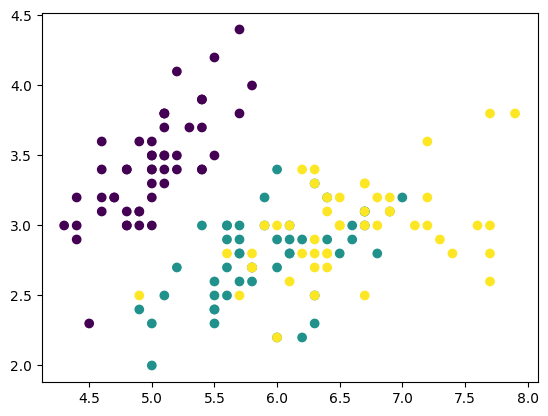

In [ ]:
# plt.scatter(x, y, c, cmap)   -> Syntax for scatter plot

plt.scatter(df['sepal length (cm)'], df['sepal width (cm)'], c=df['target'], cmap='viridis')

In [10]:
X = df.iloc[:, 0:1]
y = df.iloc[:, -1]

In [11]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [13]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [15]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Text(0, 0.5, 'Sepal Width')

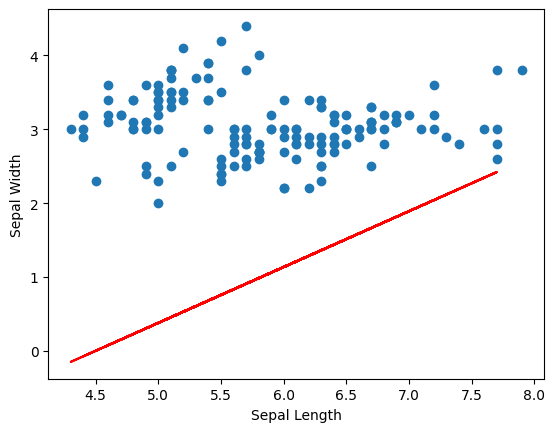

In [18]:
plt.scatter(df['sepal length (cm)'], df['sepal width (cm)'])
plt.plot(X_train, lr.predict(X_train), color = 'red')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [21]:
y_pred = lr.predict(X_test)

In [22]:
y_test.values

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [23]:
print("MAE: ", mean_absolute_error(y_test, y_pred))

MAE:  0.3833269529679363


In [24]:
print("MSE: ", mean_squared_error(y_test, y_pred))

MSE:  0.1979546681395589


In [27]:
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))

RMSE:  0.35471130306132137


In [30]:
print("R²: ", r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

R²:  0.8199712278735858


In [31]:
# Adjusted R2 score
X_test.shape

(30, 1)

In [32]:
1 - ((1-r2) * (30-1) / (30-1-1))

0.813541628869071

In [41]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(150)

new_df1 = new_df1[['sepal length (cm)', 'sepal width (cm)']]
new_df1.head(2)

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0


Text(0, 0.5, 'sepal length (cm)')

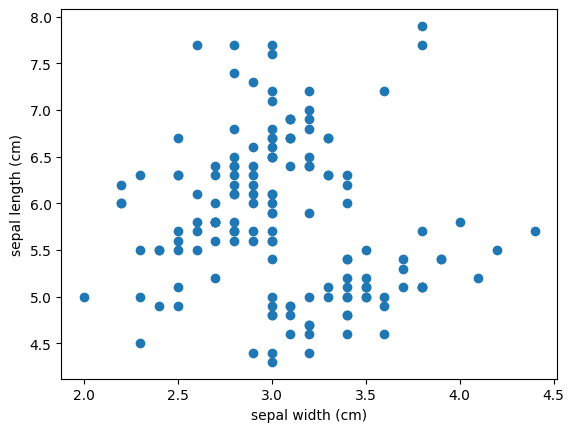

In [43]:
plt.scatter(new_df1['sepal width (cm)'], new_df1['sepal length (cm)'])
plt.xlabel('sepal width (cm)')
plt.ylabel('sepal length (cm)')

In [44]:
X = new_df1.iloc[:, 0:2]
y = new_df1.iloc[:, -1]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [46]:
lr = LinearRegression()

In [47]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
y_pred = lr.predict(X_test)

In [49]:
print("R2 score", r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

R2 score 1.0


In [50]:
1 - ((1-r2) * (30-1) / (30-1-1))

1.0

In [54]:
# Create a copy of the original DataFrame
# So changes made here do not affect the original 'df'
new_df2 = df.copy()

# Replace (or create) the 'petal length (cm)' column
# by taking the 'petal width (cm)' values and adding small random noise
# np.random.randint(-12, 2, 150) generates 150 random integers from -12 to 1
# Dividing by 100 converts them into decimal values between -0.12 and 0.01
new_df2['petal length (cm)'] = new_df2['petal width (cm)'] + (np.random.randint(-12, 2, 150) / 100)

# Keep only the 'petal length (cm)' and 'petal width (cm)' columns
new_df2 = new_df2[['petal length (cm)', 'petal width (cm)']]

In [55]:
new_df2.sample()

,petal length (cm),petal width (cm)
53,1.29,1.3


Text(0, 0.5, 'sepal width (cm)')

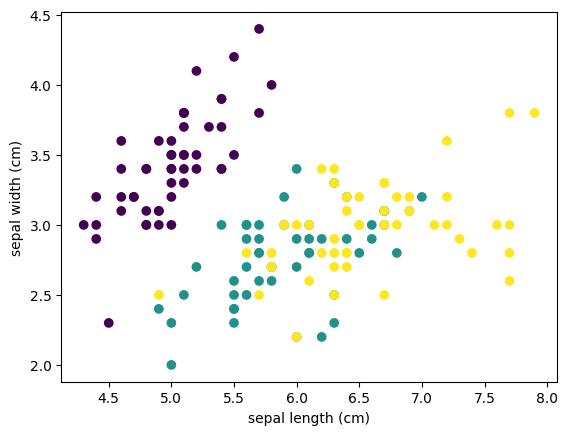

In [56]:
plt.scatter(df['sepal length (cm)'], df['sepal width (cm)'], c=df['target'])
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')

In [57]:
np.random.randint(-100, 100)

86

In [58]:
X = new_df2.iloc[:, 0:1]
y = new_df2.iloc[:, -1]

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [60]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [61]:
print("R2 score", r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

R2 score 0.9977873962022291


In [63]:
1 - ((1 - r2) * (40 - 1 ) / (40 - 1 - 2))

0.9976677959969442